STUDENT GRADE PREDICTION


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import metrics
df = pd.read_excel('cgpaPRED.xls')
display(df.head())


,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03


understand the data

In [11]:
print(df.shape)


(379, 5)


In [12]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEM 1   379 non-null    float64
 1   SEM 2   379 non-null    float64
 2   SEM 3   379 non-null    float64
 3   SEM 4   379 non-null    float64
 4   SEM 5   379 non-null    float64
dtypes: float64(5)
memory usage: 14.9 KB


In [13]:

df.describe()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
count,379.000000,379.000000,379.000000,379.000000,379.000000
mean,5.908707,6.015858,6.103852,6.167546,6.050765
std,3.147572,3.139440,3.078922,3.131259,3.091451
min,0.100000,0.100000,0.130000,0.120000,0.140000
25%,4.080000,4.275000,4.870000,4.990000,4.290000
50%,7.150000,7.240000,7.500000,7.450000,7.420000
75%,8.190000,8.320000,8.225000,8.440000,8.220000
max,9.800000,9.880000,9.730000,9.880000,9.640000


In [14]:
print("Missing values:\n", df.isnull().sum())


Missing values:
 SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64


In [15]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 48


identifieng the lebel

In [16]:
X = df[['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4']]
y = df['SEM 5']

In [17]:
target = 'SEM 5'

In [18]:
df.head()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03


make a train - test split

In [19]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (303, 4)  Test size: (76, 4)


identify the relevent features which are highly corelated to each other

In [20]:

corr = df.corr()

heatmap visualization

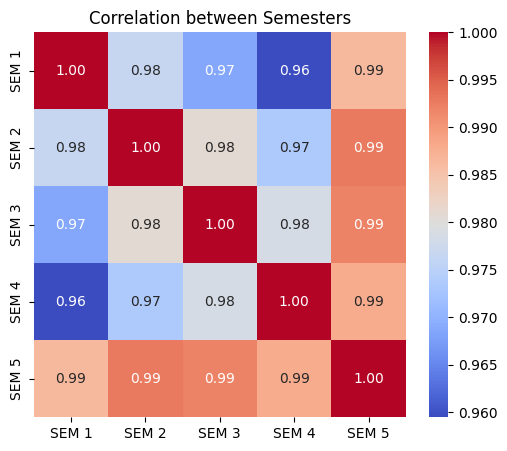

In [21]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Semesters')
plt.show()

represent the data distribution across features(box- plot visualization)

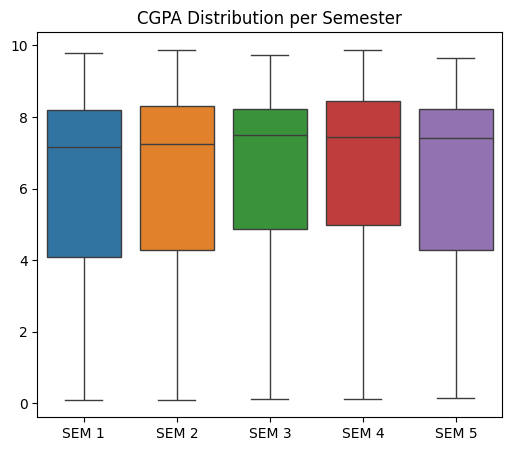

In [22]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df)
plt.title('CGPA Distribution per Semester')
plt.show()

linear regression

In [23]:
X = df[['SEM 4']]
y = df['SEM 5']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
m = model.coef_[0]
c = model.intercept_
print("m (slope):", m)
print("c (intercept):", c)
y_pred = model.predict(X_test)
for actual, predicted in zip(y_test[:5], y_pred[:5]):
    print("Actual:", actual, " Predicted:", predicted)

m (slope): 0.9773992527179318
c (intercept): 0.0326001302027219
Actual: 1.41  Predicted: 0.9024854651216813
Actual: 1.03  Predicted: 0.14988804052887372
Actual: 0.59  Predicted: 0.8438415099586053
Actual: 8.67  Predicted: 8.506651651267191
Actual: 6.31  Predicted: 6.864620906701066


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 0.3557
MSE: 0.2284
RMSE: 0.4779
R2 Score: 0.9780


scatter plot of lr

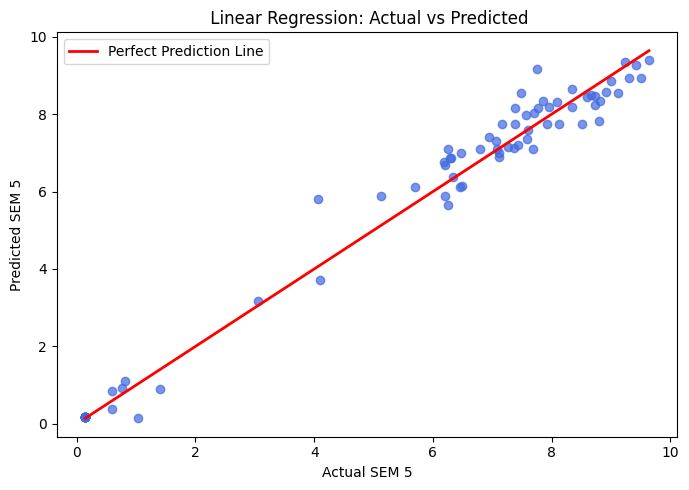

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual SEM 5')
plt.ylabel('Predicted SEM 5')
plt.title(' Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

evaluated matrices

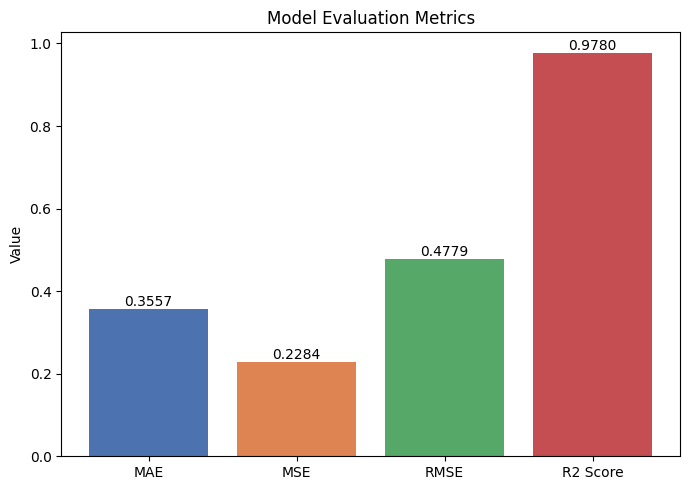

In [27]:
metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}

plt.figure(figsize=(7,5))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.4f}', ha='center', va='bottom')
plt.title('Model Evaluation Metrics')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

multiple linear regression

In [28]:
X = df[['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4']]
y = df['SEM 5']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
c = model.intercept_
b1, b2, b3, b4 = model.coef_
print("c (intercept):", c)
print("b1 (SEM 1):", b1)
print("b2 (SEM 2):", b2)
print("b3 (SEM 3):", b3)
print("b4 (SEM 4):", b4)
y_pred = model.predict(X_test)
y_pred_manual = (
    c
    + b1 * X_test['SEM 1']
    + b2 * X_test['SEM 2']
    + b3 * X_test['SEM 3']
    + b4 * X_test['SEM 4']
)
comparison = pd.DataFrame({
    'sklearn_pred': y_pred,
    'manual_formula_pred': y_pred_manual.values
})
print(comparison.head())

c (intercept): 0.0035713111292468014
b1 (SEM 1): 0.24985025719801038
b2 (SEM 2): 0.2502485944749779
b3 (SEM 3): 0.249937703220696
b4 (SEM 4): 0.24966538902885285
   sklearn_pred  manual_formula_pred
0      1.413313             1.413313
1      1.030991             1.030991
2      0.588189             0.588189
3      8.668548             8.668548
4      6.311410             6.311410


In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.0023391696650216596
MSE: 7.162756055514429e-06
RMSE: 0.00267633257565543
R2: 0.9999993113342205


scatter plot of mlr

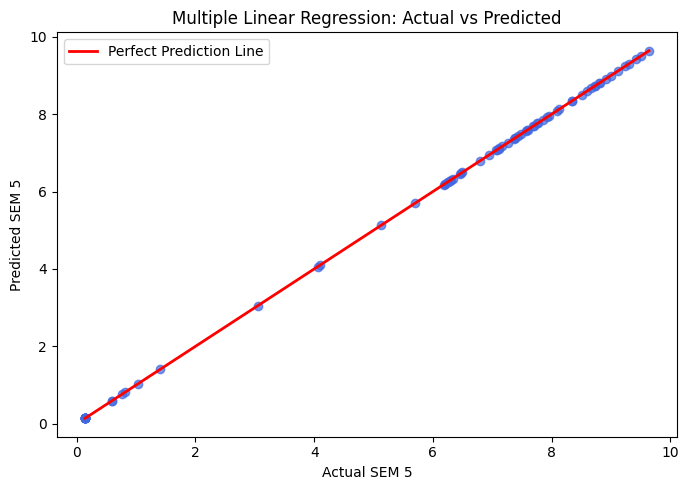

In [30]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual SEM 5')
plt.ylabel('Predicted SEM 5')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

evaluated matrices of mlr

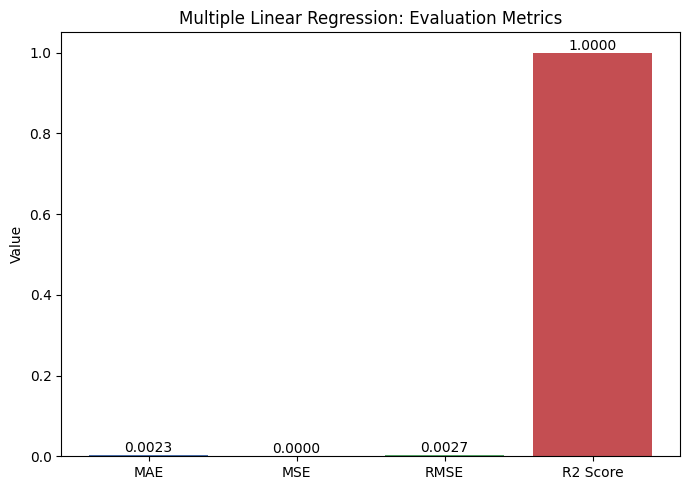

In [31]:
metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}
plt.figure(figsize=(7,5))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.4f}', ha='center', va='bottom')
plt.title('Multiple Linear Regression: Evaluation Metrics')
plt.ylabel('Value')
plt.tight_layout()
plt.show()